CNN-LSTM model with 10 feature (Open, High, Low, Close, Volume, SMA_10, RSI_14, ATR_14) + Financial News Sentiment
Target: Future Close Price

Most recently ran on 17-03-2026

This model only contains 10 featurse instead of 11 as adding the volume-based technical indicator increased error and reduced the overall performance of the model.

Importing all the necessary Libraries 

In [1]:
#Standard library
import os
import random
from datetime import datetime, timedelta

#Data manipulation and numerical computing
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Machine learning preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

#TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, LSTM, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

##Technical Indicators 
import ta
from ta.trend import SMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator 

#Financial data
import yfinance as yf

Removing randomness from the model to enforce consistent results

In [2]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

In [3]:
#Loading the sentiment CSV file before passing it to the LSTM
sentiment_df = pd.read_csv("daily_apple_news_sentiment.csv")

#Converts the date column into a proper datetime object
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

Function to fetch and download data (Apple Stock Price) from Yahoo everyday roughly for the past 10 years 

In [4]:
ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01", end="2026-03-16")

#When you first download stock data using yf.download() the resulting dataframe uses date as the index (row labels)
#Here we are moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

# Flatten the column names if they're MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.head())

#Trend Indicator
sma10 = SMAIndicator(data['Close'], window=10).sma_indicator()
data['SMA_10'] = data['Close'] / sma10

#Momentum Indicator
data['RSI_14'] = RSIIndicator(data['Close'], window=14).rsi()

#Volatility Indicator
atr_val = AverageTrueRange(data['High'], data['Low'], data['Close'], window=14).average_true_range()
data['ATR_14'] = atr_val / data['Close']

#data.to_csv("Before.csv", index=False)

#Merge sentiment with stock data using left join (add sentiment data where available)
data = data.merge(
    sentiment_df,
    left_on="Date",
    right_on="date",
    how="left"
)

#Add a new column to the original dataframe 
#Not all days have a sentiment value so add a 0 for all missing sentiment days
data["avg_sentiment"] = data["avg_sentiment"].fillna(0)

#The model cannot differentiate between 0 being a sentiment score and 0 being no news 
#so adding a binary column that gives the model context to only look at days with news

#A binary feature that tells the model whether news exists that day
data["has_news"] = (data["avg_sentiment"] != 0).astype(int)

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(method='ffill', inplace=True) 
data.dropna(inplace=True)  

#data.to_csv("After.csv", index=False)

# Define feature 
price_features = ['Close', 'Open', 'High', 'Low', 'Volume', 'SMA_10', 'RSI_14', 'ATR_14']
sentiment_features = ['avg_sentiment', 'has_news']

#Extract specific columns from your DataFrame and converts them into a NumPy array.
price_data = data[price_features].values
sentiment_data = data[sentiment_features].values
datetime_index = data['Date'].values

C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_24612\819145205.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2026-03-16")
[*********************100%***********************]  1 of 1 completed

Price       Date      Close       High        Low       Open     Volume
0     2015-01-02  24.214888  24.682220  23.776348  24.671145  212818400
1     2015-01-05  23.532717  24.064280  23.346671  23.984545  257142000
2     2015-01-06  23.534937  23.794073  23.173916  23.596952  263188400
3     2015-01-07  23.864944  23.964612  23.632385  23.743127  160423600
4     2015-01-08  24.781897  24.839483  24.075361  24.192749  237458000



C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_24612\819145205.py:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [5]:
# Get the number of close prices
print(f"Number of close prices: {len(data)}")

Number of close prices: 2802


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [6]:
total_size = len(data)

train_size = int(len(data) * 0.70)
val_size = int(len(data) * 0.15)

# Split Price Data (for scaling)
train_price = price_data[:train_size]
val_price = price_data[train_size:train_size + val_size]
test_price = price_data[train_size + val_size:]

# Split Sentiment Data (no scaling needed)
train_sent = sentiment_data[:train_size]
val_sent = sentiment_data[train_size:train_size + val_size]
test_sent = sentiment_data[train_size + val_size:]

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_price)} samples ({len(train_price)/total_size:.2%})")
print(f"Validation set : {len(val_price)} samples ({len(val_price)/total_size:.2%})")
print(f"Test set       : {len(test_price)} samples ({len(test_price)/total_size:.2%})")

print("Train:", train_price.shape)
print("Val  :", val_price.shape)
print("Test :", test_price.shape)

print("\nCheck sum:", len(train_price) + len(val_price) + len(test_price))

Total samples: 2802

Dataset sizes:
Training set   : 1961 samples (69.99%)
Validation set : 420 samples (14.99%)
Test set       : 421 samples (15.02%)
Train: (1961, 8)
Val  : (420, 8)
Test : (421, 8)

Check sum: 2802


Normalizing my data using a Min-Max Scaler. But only using only the training data as the scaler to prevent data leaks

In [7]:
#Calculating the number of features, and creating a seperate scaler for each feature
num_features = train_price.shape[1]
scalers = [MinMaxScaler(feature_range=(0, 1)) for _ in range(num_features)]

#Fit each scaler on only the training data for that specific column - this avoids data leaks
#Here we just calculate and store the min and max values for each feature
for i, scaler in enumerate(scalers):
    scaler.fit(train_price[:, [i]])

#Transform each column individually using its corresponding scaler
#Transforming means actually applying the MinMax formula to get new values between 0-1
#np.hstack then stacks the scaled columns back together horizontally
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

#All three datasets are transformed using the scalers fitted on the training data
train_price_scaled = scale_data(train_price, scalers)
val_price_scaled = scale_data(val_price, scalers)
test_price_scaled = scale_data(test_price, scalers)

print("Train scaled min/max:", train_price_scaled.min(), train_price_scaled.max())
print("Val   scaled min/max:", val_price_scaled.min(), val_price_scaled.max())
print("Test  scaled min/max:", test_price_scaled.min(), test_price_scaled.max())

Train scaled min/max: 0.0 1.0000000000000002
Val   scaled min/max: -0.027889103643613328 1.318660290800623
Test  scaled min/max: -0.18408759910772243 1.695720060979412


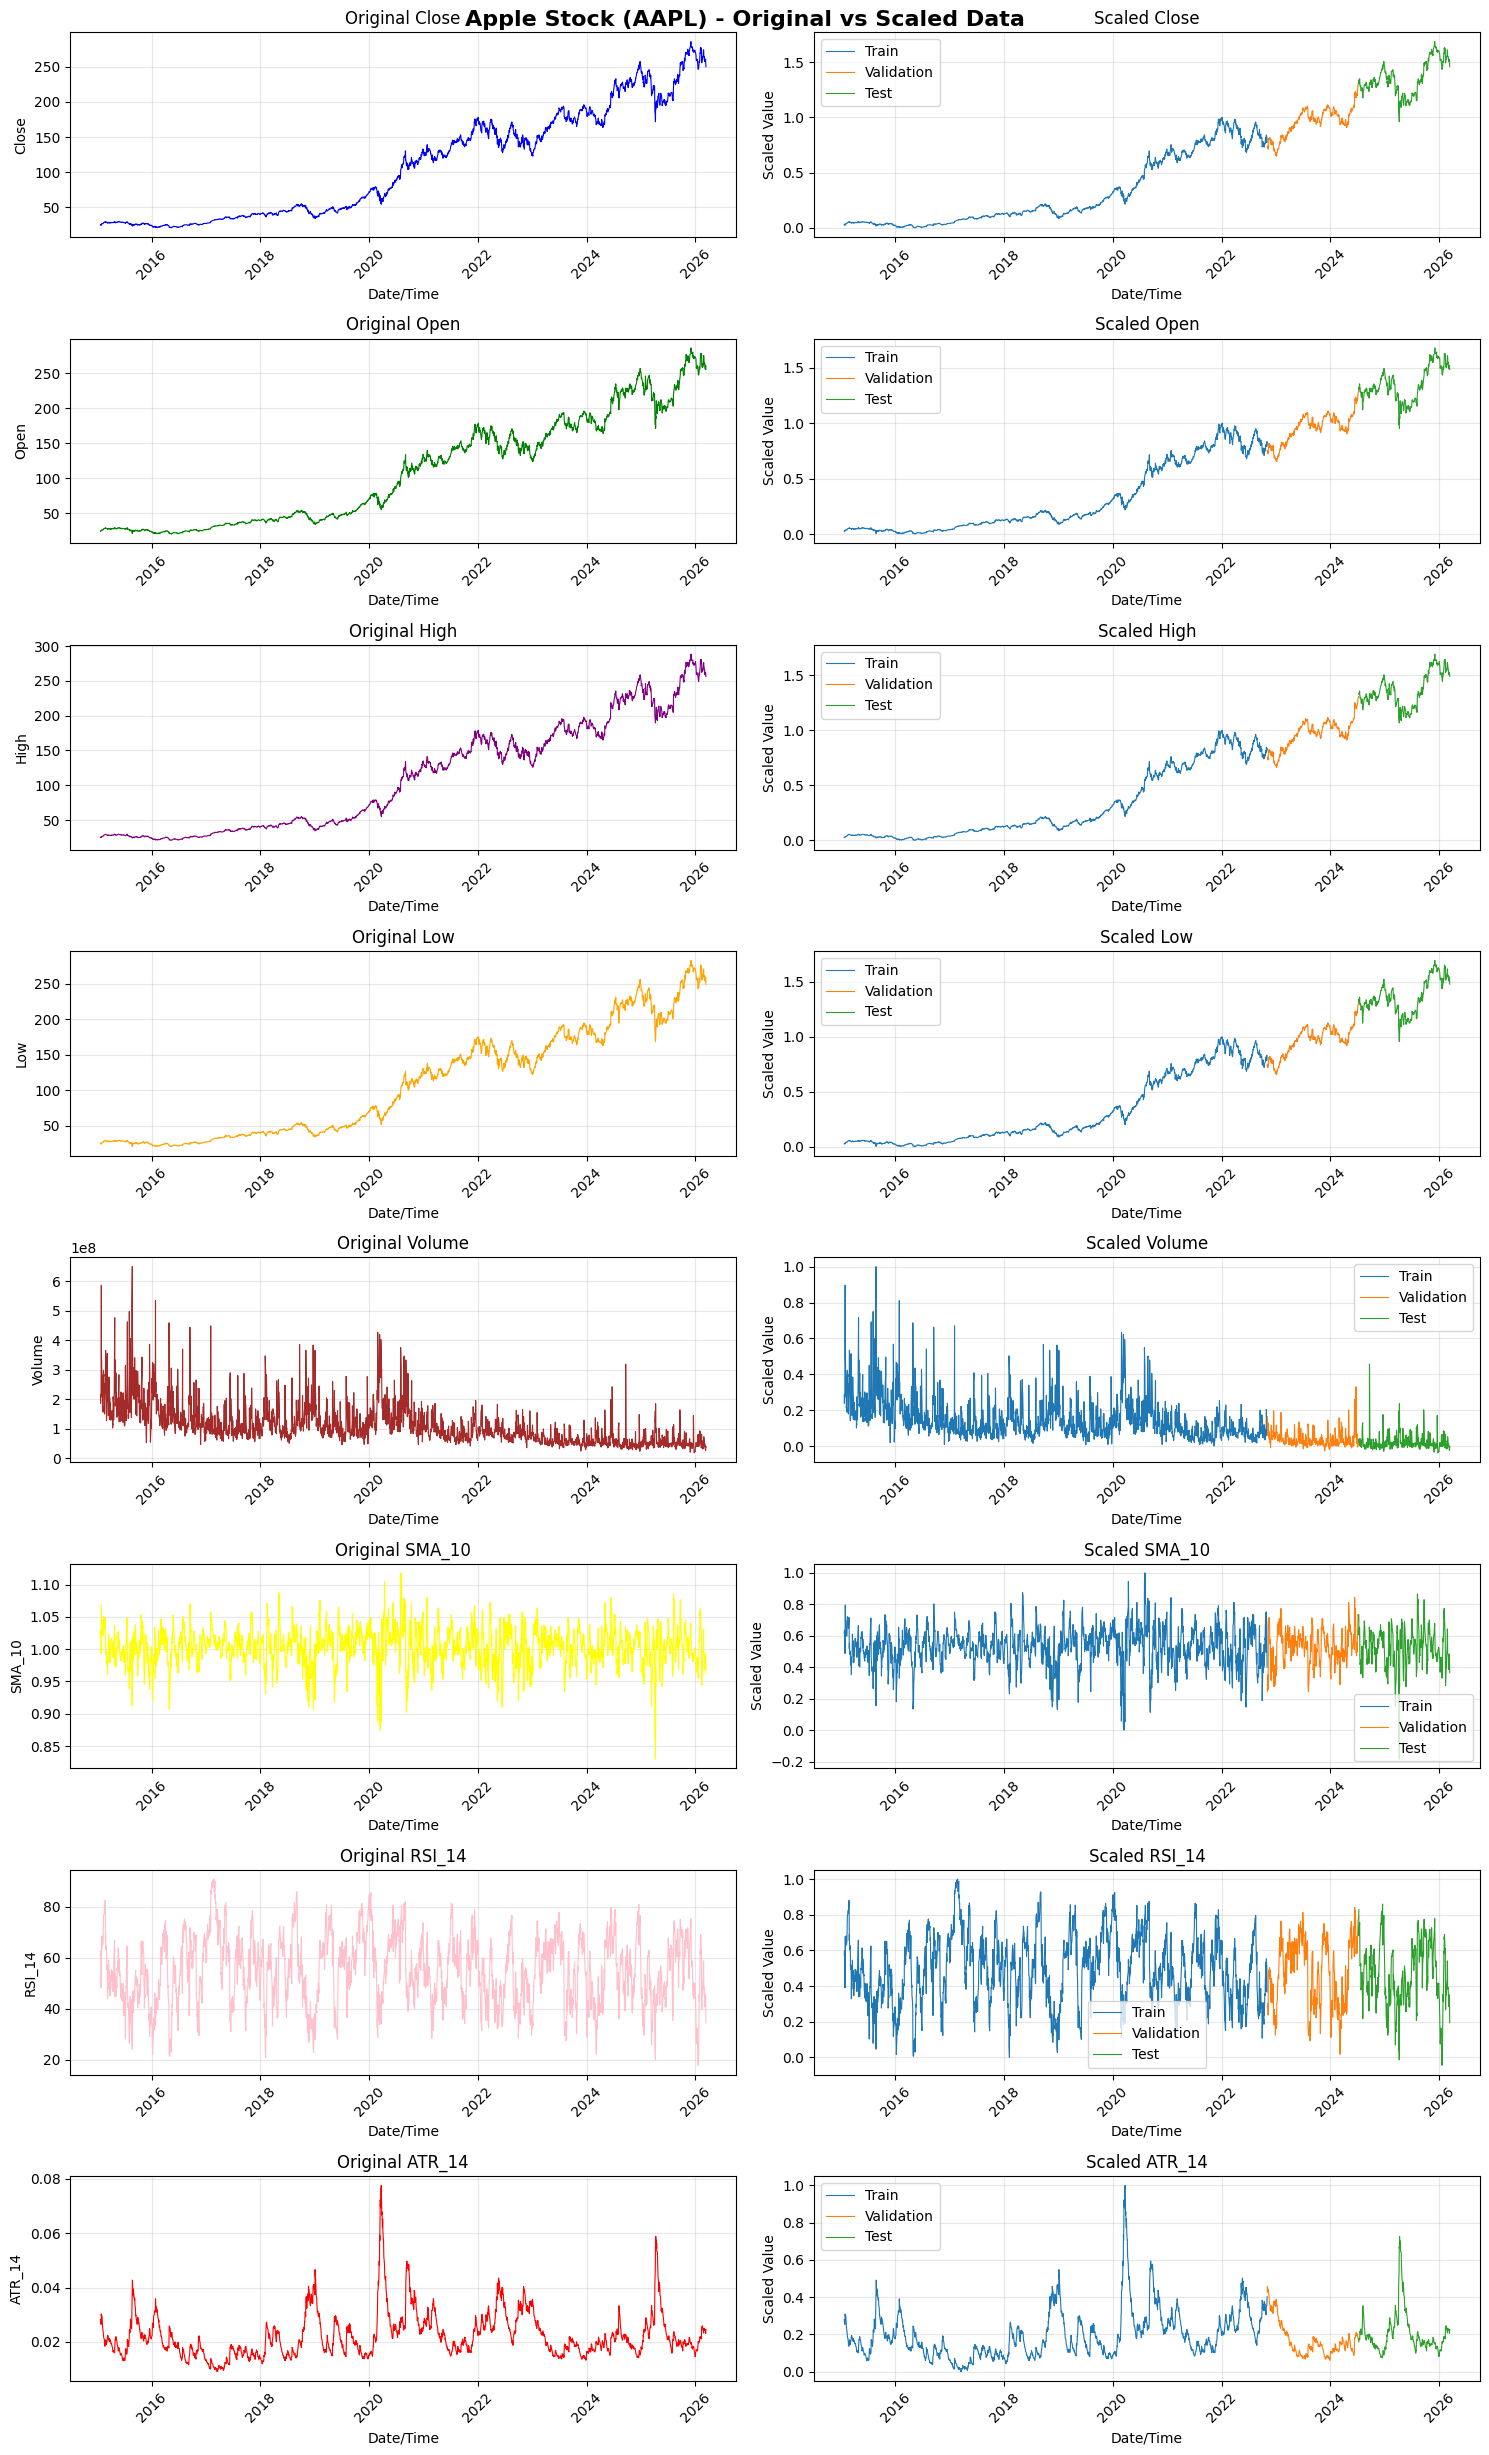

In [8]:
# Reconstructing datetime splits to match data splits
datetime_train = datetime_index[:train_size]
datetime_val   = datetime_index[train_size:train_size + val_size]
datetime_test  = datetime_index[train_size + val_size:]

num_features = train_price.shape[1]

# Create 8x2 subplot layout for both features
fig, axes = plt.subplots(num_features, 2, figsize=(15, 25))
fig.suptitle(
    'Apple Stock (AAPL) - Original vs Scaled Data',
    fontsize=16,
    fontweight='bold'
)

feature_titles = ['Close', 'Open', 'High', 'Low', 'Volume', 'SMA_10', 'RSI_14', 'ATR_14']
colors = ['blue', 'green', 'purple', 'orange', 'brown', 'yellow', 'pink', 'red']

for i in range(num_features):
    # Original
    axes[i, 0].plot(datetime_index, price_data[:, i], color=colors[i], linewidth=0.8)
    axes[i, 0].set_title(f'Original {feature_titles[i]}')
    axes[i, 0].set_xlabel('Date/Time')
    axes[i, 0].set_ylabel(feature_titles[i])
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Scaled
    axes[i, 1].plot(datetime_train, train_price_scaled[:, i], label='Train', linewidth=0.8)
    axes[i, 1].plot(datetime_val, val_price_scaled[:, i], label='Validation', linewidth=0.8)
    axes[i, 1].plot(datetime_test, test_price_scaled[:, i], label='Test', linewidth=0.8)
    axes[i, 1].set_title(f'Scaled {feature_titles[i]}')
    axes[i, 1].set_xlabel('Date/Time')
    axes[i, 1].set_ylabel('Scaled Value')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Stack scaled prices with unscaled sentiment
train_final = np.hstack([train_price_scaled, train_sent])
val_final = np.hstack([val_price_scaled, val_sent])
test_final = np.hstack([test_price_scaled, test_sent])

all_cols = price_features + sentiment_features

datasets = {
    "Train": train_final,
    "Validation": val_final,
    "Test": test_final
}

#Loop through the dictionary items
for name, dataset_array in datasets.items():
    rows, cols = dataset_array.shape
    print(f"{name} Set - Rows: {rows}, Columns: {cols}")

Train Set - Rows: 1961, Columns: 10
Validation Set - Rows: 420, Columns: 10
Test Set - Rows: 421, Columns: 10


Creating a Slidng Window to prepare the input data for the CNN model

In [10]:
def create_multifeature_dataset_with_context(data, time_step, context_data = None):

    if context_data is not None:
        data = np.vstack([context_data[-time_step:], data])

    X, y = [] ,[]

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, :])  #here we grab all columns and rows per timesteps (rows 0-95 first time)
        y.append(data[i + time_step, 0])  #here we only predict the Close price (row 96)

    #Convert the lists to NumPy arrays for compatibility with neural network frameworks
    return np.array(X), np.array(y)

time_step = 10

X_train, y_train = create_multifeature_dataset_with_context(train_final, time_step)
X_val, y_val     = create_multifeature_dataset_with_context(val_final, time_step, context_data=train_final)
X_test, y_test   = create_multifeature_dataset_with_context(test_final, time_step, context_data=val_final)

# Check shapes
print("Shapes of LSTM datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")

Shapes of LSTM datasets:
X_train: (1951, 10, 10), y_train: (1951,)
X_val  : (420, 10, 10), y_val  : (420,)
X_test : (421, 10, 10), y_test : (421,)


In [11]:
model = Sequential()

#Conv layer + Pooling
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(Conv1D(32, kernel_size=5, padding='same', activation='relu'))
model.add(Conv1D(32, kernel_size=5, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.15))

#LSTM layer 
model.add(LSTM(units=128, return_sequences=False))
model.add(Dropout(0.25))

model.add(Dense(64, activation='relu'))
model.add(Dense(1)) 

model.compile(optimizer=Adam(learning_rate=1e-4), loss='mean_squared_error', metrics=['MAE'])

#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,          
    patience=5,          
)

callbacks = [early_stop, reduce_lr]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=150,
    batch_size=32,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

Epoch 1/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - MAE: 0.0996 - loss: 0.0193 - val_MAE: 0.0404 - val_loss: 0.0027 - learning_rate: 1.0000e-04
Epoch 2/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MAE: 0.1891 - loss: 0.0498 - val_MAE: 0.0358 - val_loss: 0.0019 - learning_rate: 1.0000e-04
Epoch 3/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - MAE: 0.1029 - loss: 0.0154 - val_MAE: 0.0322 - val_loss: 0.0017 - learning_rate: 1.0000e-04
Epoch 4/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - MAE: 0.0555 - loss: 0.0051 - val_MAE: 0.0299 - val_loss: 0.0014 - learning_rate: 1.0000e-04
Epoch 5/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - MAE: 0.0481 - loss: 0.0040 - val_MAE: 0.0294 - val_loss: 0.0013 - learning_rate: 1.0000e-04
Epoch 6/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - MAE: 0.0445 - loss: 0.0034 - val_MAE: 0.0265 - val_loss: 0.0011 - learning_rate: 1.0000e-04
Epoch 7/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MAE: 0.0426 - loss: 0.0033 - val_MAE: 0.0248 - val_loss: 0.0010 - learning_r

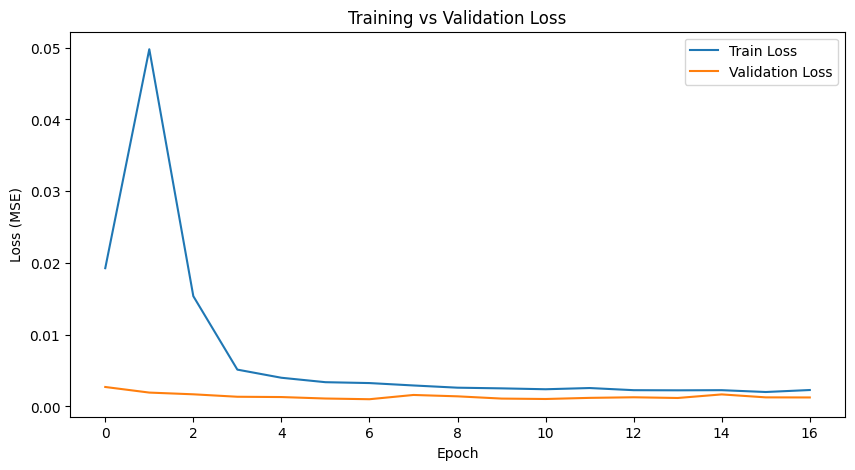

In [12]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [13]:
#This gets the predictions from the model - but these are scaled from (0-1 range) beacuse the model was trained on scaled data
predictions_scaled = model.predict(X_test)

# Inverse transform reverses the scaling applied earlier and converts predictions from 0-1 range back to actual dollar values
predictions = scalers[0].inverse_transform(predictions_scaled)
y_test_unscaled = scalers[0].inverse_transform(y_test.reshape(-1, 1))

# Flatten the 2D array back to 1D arrays which is easier for metrics calculations
predictions = predictions.flatten()
y_test_unscaled = y_test_unscaled.flatten()

# Calculate metrics on unscaled data
#RMSE (Root Mean Squared Error): Average prediction error, penalizes large errors more
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))

#MAE (Mean Absolute Error): Average absolute difference between predicted and actual prices
mae = mean_absolute_error(y_test_unscaled, predictions)

print(f"\nUnscaled Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Unscaled Mean Absolute Error (MAE): ${mae:.2f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Unscaled Root Mean Squared Error (RMSE): $8.61
Unscaled Mean Absolute Error (MAE): $6.74


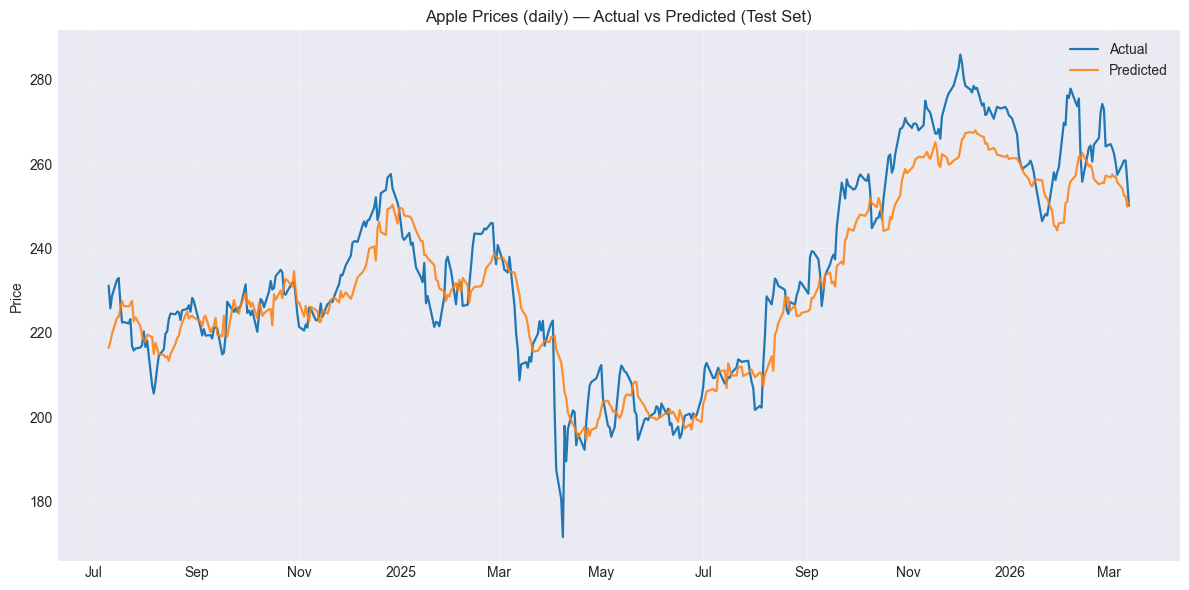

In [14]:
dates_test = datetime_index[-len(predictions):]

#Plot with real dates on the x-axis
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_unscaled.flatten(), label="Actual", linewidth=1.6)
plt.plot(dates_test, predictions.flatten(), label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Prices (daily) — Actual vs Predicted (Test Set)")
plt.ylabel("Price")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show() 

Checking the Accuracy of my models:

In [15]:
# --- Directional Accuracy ---

# Actual and predicted price changes
actual_direction = np.sign(np.diff(y_test_unscaled))
predicted_direction = np.sign(np.diff(predictions))

# Directional accuracy
directional_accuracy = np.mean(actual_direction == predicted_direction)

print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%") 

Directional Accuracy: 51.19%


In [16]:
# --- MAPE-based Accuracy ---

mape = np.mean(np.abs((y_test_unscaled - predictions) / y_test_unscaled)) * 100
accuracy_mape = 100 - mape

print(f"MAPE: {mape:.2f}%")
print(f"MAPE-based Accuracy: {accuracy_mape:.2f}%")

MAPE: 2.84%
MAPE-based Accuracy: 97.16%


-- BackTesting --

In [17]:
START_DATE = '2024-07-11'
start_idx = next(i for i, d in enumerate(datetime_test)
                 if pd.Timestamp(d).date() >= pd.to_datetime(START_DATE).date())

datetime_test_aligned = datetime_test[start_idx:]
test_price_aligned    = test_price[start_idx:]
test_sent_aligned     = test_sent[start_idx:]
predictions_aligned   = predictions.flatten()[start_idx:]


In [18]:
#Create a DataFrame for backtesting
backtest_df = pd.DataFrame({
    'Date': datetime_test_aligned,
    'Actual_Open': test_price_aligned[:, 1], 
    'Actual_Close': test_price_aligned[:, 0],
    'Predicted_Close': predictions_aligned.flatten(),
    'Sentiment' : test_sent_aligned[:, 0],
    #Converting ATR from a percentage back to dollars 
    'ATR_Dollar': test_price_aligned[:, 7] * test_price_aligned[:, 0]
})

In [19]:
#Ensure all features are the same length 
print(f"Dates: {len(datetime_test_aligned)}")
print(f"Actual Open: {len(test_price_aligned[:, 1])}")
print(f"Actual Close: {len(test_price_aligned[:, 0])}")
print(f"Predictions: {len(predictions_aligned.flatten())}")
print(f"Sentiment: {len(test_sent_aligned[:, 0])}")
print(f"ATR: {len(test_price_aligned[:, 7])}")
print(f"Test set starts: {pd.Timestamp(datetime_test_aligned[0]).date()}")
print(f"Test set ends:   {pd.Timestamp(datetime_test_aligned[-1]).date()}")

Dates: 420
Actual Open: 420
Actual Close: 420
Predictions: 420
Sentiment: 420
ATR: 420
Test set starts: 2024-07-11
Test set ends:   2026-03-13


In [20]:
#Shift prices and features to avoid look ahead bias
backtest_df['Previous_Close'] = backtest_df['Actual_Close'].shift(1)
backtest_df['Prev_Sentiment'] = backtest_df['Sentiment'].shift(1)
backtest_df['Prev_ATR'] = backtest_df['ATR_Dollar'].shift(1)

#Predicting returns based on previous close
backtest_df['Pred_Return'] = (backtest_df['Predicted_Close'] - backtest_df['Previous_Close']) / backtest_df['Previous_Close']

#backtest_df.to_csv("Before.csv", index=False)

#Defining signal logic based on returns and thresholds
def get_signal(row, threshold=0.005):
    if row['Pred_Return'] > threshold and row['Prev_Sentiment'] > 0:
        return 1
    #Sell signal created when returns is negative OR negative sentiment
    elif row['Pred_Return'] < -threshold or row['Prev_Sentiment'] < 0:
        return -1
    else:
        return 0

#Create a new column in the dataframe to save signals 
backtest_df['Signal'] = backtest_df.apply(get_signal, axis=1)
backtest_df = backtest_df.dropna().reset_index(drop=True)

#backtest_df.to_csv("After.csv", index=False)


In [21]:
print(f"Signal distribution:")
print(backtest_df['Signal'].value_counts())

print(f"Days where Pred_Return > 0.005: {(backtest_df['Pred_Return'] > 0.005).sum()}")
print(f"Days where Prev_Sentiment > 0:  {(backtest_df['Prev_Sentiment'] > 0).sum()}")
print(f"Days where BOTH true:           {((backtest_df['Pred_Return'] > 0.005) & (backtest_df['Prev_Sentiment'] > 0)).sum()}")


Signal distribution:
Signal
-1    261
 0    143
 1     15
Name: count, dtype: int64
Days where Pred_Return > 0.005: 108
Days where Prev_Sentiment > 0:  92
Days where BOTH true:           15


In [22]:
#Initialization of backtesting variables
initial_cash_amount = 10000.0
cash_balance = initial_cash_amount
transaction_fee = 0.001  #0.1% transaction fee per trade
risk_per_trade = 0.02 #Risk 2% of total cash per trade
portfolio_values = [] #Being used to keep track of total cash at the end of each day
shares_held = 0
is_holding = False
trade_log = [] #1 for Buy, -1 for Sell, 0 for Hold/Flat


#Main Backtesting Loop
for i in range(len(backtest_df)):
    row = backtest_df.iloc[i]
    signal = row['Signal']
    open_price = row['Actual_Open']
    close_price = row['Actual_Close']
    atr = row['Prev_ATR']

    #Exit if shares have already been bought and recieve a sell signal (-1) or sentiment turns negative
    if is_holding and signal == -1:
        #sell the shares at todays opening price (as predictions are lagged)
        cash_balance += shares_held * open_price * (1 - transaction_fee)
        shares_held = 0
        is_holding = False
        trade_log.append(-1)
    
    #Enter if we no shares are already bough and recieve a buy signal (1)
    elif not is_holding and signal == 1:
        #First calculate how much money you are willing to risk
        risk_dollars = (cash_balance + (shares_held * open_price)) * risk_per_trade

        #Then use ATR to convert money into shares
        shares_to_buy = int(risk_dollars / atr)
        
        #Checking you are never buying more shares than you can actually afford 
        max_affordable = int(cash_balance / (open_price * (1 + transaction_fee)))
        shares_to_buy = min(shares_to_buy, max_affordable)
        
        #Execute the buy and deduct money spent from cash balance 
        if shares_to_buy > 0:
            cash_balance -= shares_to_buy * open_price * (1 + transaction_fee)
            shares_held = shares_to_buy
            is_holding = True
            trade_log.append(1)
        else:
            trade_log.append(0)

    #Signal of 0 means do nothing, continue to hold       
    else:
        trade_log.append(0)

    #Calculate the total amount of cash at the end of the day
    portfolio_values.append(cash_balance + (shares_held * close_price))
    

backtest_df['Portfolio_Value'] = portfolio_values
backtest_df['Trade_Action'] = trade_log

#The final amount of (cash made/lost) from the backtesting strategy
final_val = backtest_df['Portfolio_Value'].iloc[-1]

Building a Buy And Hold BenchMark - Used for comaparison 

Idea: Buy shares at day 1, and see what they are worth at the end

In [23]:
#First buy as many shares as possible on day one 
bench_shares = (initial_cash_amount * (1 - transaction_fee)) / backtest_df['Actual_Open'].iloc[0]

#Value the values of the bought shares every day
backtest_df['Benchmark_Value'] = bench_shares * backtest_df['Actual_Close']

#The final value of the benchmark strategy
final_bench = backtest_df['Benchmark_Value'].iloc[-1]

In [24]:
print(f"Benchmark start: {backtest_df['Date'].iloc[0].date()}")

Benchmark start: 2024-07-12


--- Evaluating Strategy Performance ---
Final Value:    $11,218.42
Strategy ROI:   12.18%
Benchmark ROI:  10.00%
Alpha:          2.19%
Sharpe Ratio:   1.55
Max Drawdown:   -1.61%
Total Round Trips: 9
----------------------------------------


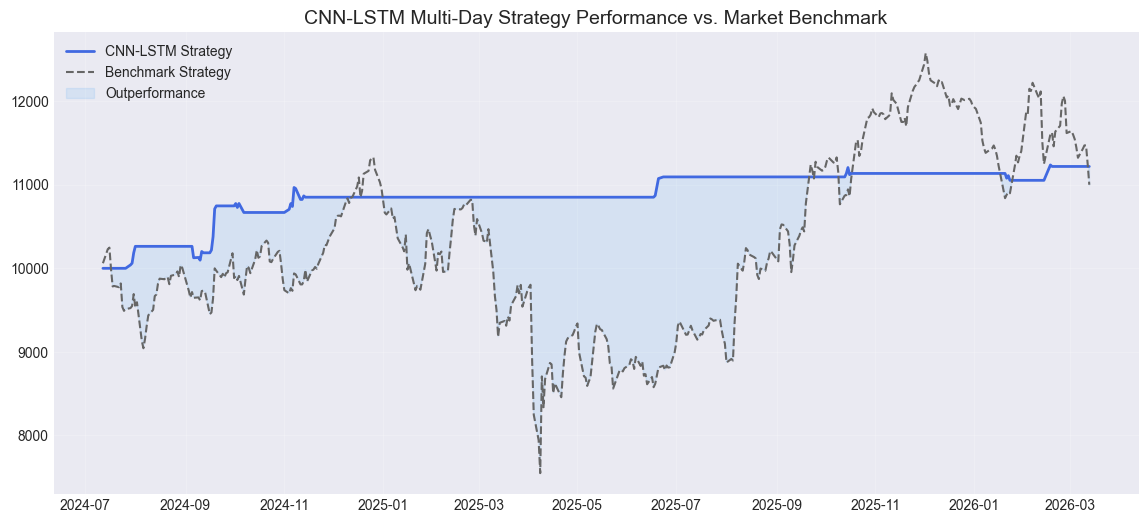

In [25]:
#Calculate Return on Investment of the backtesting and benchmark strategy  
roi = ((final_val - initial_cash_amount) / initial_cash_amount) * 100
bench_roi = ((final_bench - initial_cash_amount) / initial_cash_amount) * 100

#Alpha: Represents the excess return of the strategy relative to the benchmark
alpha = roi - bench_roi

#Sharpe Ratio: Measures the risk-adjusted return
backtest_df['Daily_Pct'] = backtest_df['Portfolio_Value'].pct_change()
sharpe = (backtest_df['Daily_Pct'].mean() / backtest_df['Daily_Pct'].std()) * np.sqrt(252)

#Calculating Maximum drawdown 
max_dd = (backtest_df['Portfolio_Value'] / backtest_df['Portfolio_Value'].cummax() - 1).min()

##Calculating the toal number of completed trades
total_buys = (backtest_df['Trade_Action'] == 1).sum()
total_sells = (backtest_df['Trade_Action'] == -1).sum()
round_trips = min(total_buys, total_sells) 

#Metrics Evaluation of Results
print(f"--- Evaluating Strategy Performance ---")
print(f"Final Value:    ${final_val:,.2f}")
print(f"Strategy ROI:   {roi:.2f}%")
print(f"Benchmark ROI:  {bench_roi:.2f}%")
print(f"Alpha:          {alpha:.2f}%")
print(f"Sharpe Ratio:   {sharpe:.2f}")
print(f"Max Drawdown:   {max_dd*100:.2f}%")
print(f"Total Round Trips: {round_trips}")
print("-" * 40)

plt.figure(figsize=(14, 6))

#Plot the strategy's daily portfolio value over time
plt.plot(backtest_df['Date'], 
         backtest_df['Portfolio_Value'], 
         label='CNN-LSTM Strategy', 
         color='royalblue', lw=2)

#Plot the benchmark portfolio value over time
plt.plot(backtest_df['Date'], 
         backtest_df['Benchmark_Value'], 
         label='Benchmark Strategy', 
         color='#666666', linestyle='--')

#Visulise where the backtesting strategy outperformed the baseline
plt.fill_between(backtest_df['Date'], 
                 backtest_df['Portfolio_Value'], 
                 backtest_df['Benchmark_Value'], 
                 where=(backtest_df['Portfolio_Value'] >= backtest_df['Benchmark_Value']), 
                 interpolate=True, color='#2196F3', alpha=0.1, label='Outperformance')

plt.title('CNN-LSTM Multi-Day Strategy Performance vs. Market Benchmark', fontsize=14)
plt.legend()
plt.grid(alpha=0.2)
plt.show()